[-2.35619449 -0.78539816  2.35619449  0.78539816]
[1. 1. 1. 1.]


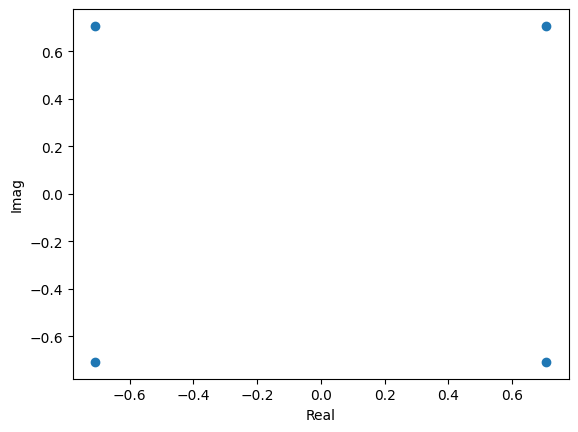

In [134]:
import numpy as np
from scipy import signal, fft
import komm
from matplotlib import pyplot as plt
from tools import *

np.random.seed(0)

DWIDTH = 20
DFRAC  = 16

msg = "A perfectly acceptable example of an extremely verbose message of large words and many characters!!!"
M = 4
fc = 1e6
br = 50e3
fs = 5e6
sps = int(fs / br)
sps_rx = 10
snr = 15
Es = 1
B = 250e3 # channel BW

sync_len = 64
zadoff_chu_len = 16
span = 10
beta = 0.5

constellation = get_const(f'{M}-QAM', Es)
print(np.angle(constellation))
print(np.abs(constellation))
write_mem_file(constellation, DWIDTH, DFRAC, 'const.mem', complex=True, sep=' ')
plot_constellation(constellation)
plt.show()

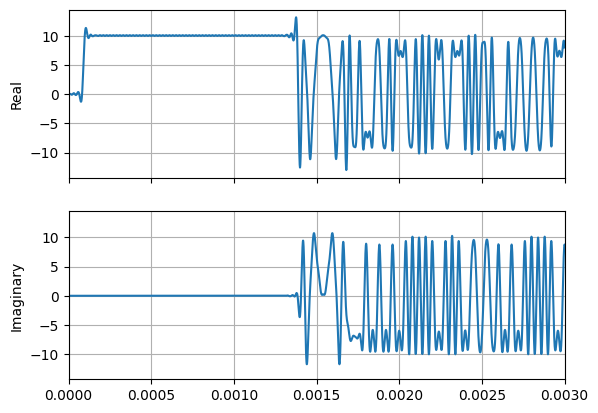

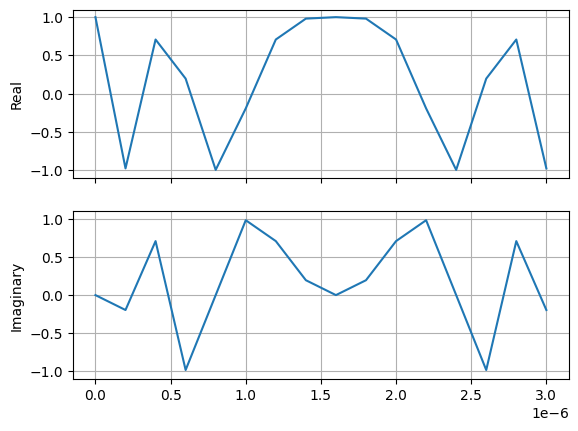

In [135]:
words = str2words(msg, M)
symbs = constellation[words]
sync_symbs = np.ones(sync_len) + 0j
zadoff_chu_seq = zadoff_chu(zadoff_chu_len)
write_mem_file(zadoff_chu_seq, DWIDTH, DFRAC, 'zadoff_chu.mem', complex=True, sep=' ')

rrc = get_rrc_pulse(beta, span, sps)
write_mem_file(rrc[::-1], DWIDTH, DFRAC, 'rrc.mem', complex=False)

# full_msg = np.convolve(upsample(np.concat((sync_symbs, zadoff_chu_seq, symbs)), sps), rrc)
full_msg = signal.resample_poly(np.pad(np.concat((sync_symbs, zadoff_chu_seq, symbs)), span//2), sps, 1, window=rrc)

fig, ax1, ax2 = plot_complex_time_sequence(full_msg, fs)
plt.xlim((0.0000, 0.003))
plt.show()

# X = fft.fftshift(fft.fft(full_msg))
# f = fft.fftshift(fft.fftfreq(len(X), fs))
# plt.figure(figsize=(20,5))
# plt.plot(f, 10*np.log10(np.abs(X)))
# Z = fft.fftshift(fft.fft(np.pad(zadoff_chu_seq, len(zadoff_chu_seq)*2)))
# f = fft.fftshift(fft.fftfreq(len(Z), fs))
# plt.plot(f, 10*np.log10(np.abs(Z)))
# plt.grid()
# plt.show()
plot_complex_time_sequence(zadoff_chu_seq, fs)
plt.show()

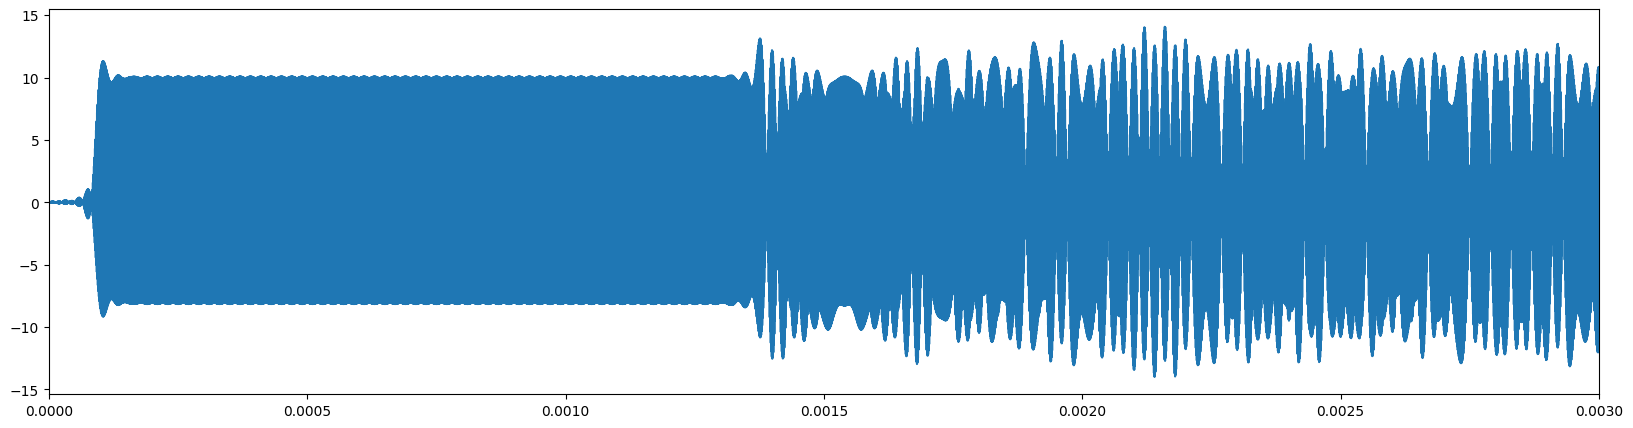

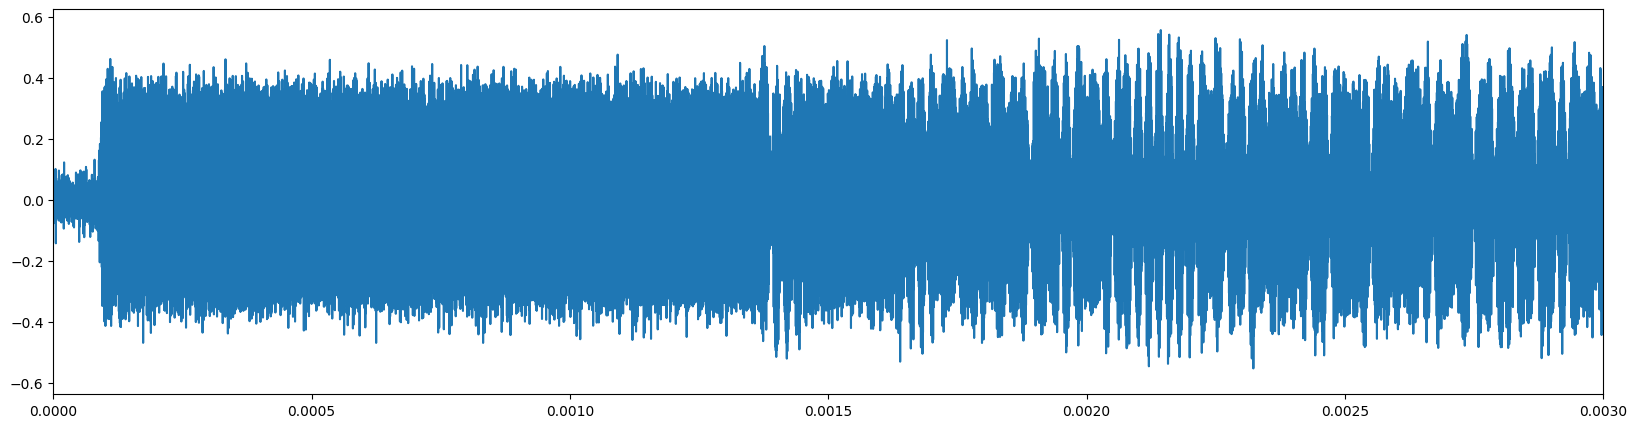

In [136]:
t = np.arange(0, len(full_msg)) / fs
x = np.real(full_msg * np.exp(2j*np.pi*fc*t))

plt.figure(figsize=(20, 5))
plt.plot(t, x)
plt.xlim((0.000, 0.003))
plt.show()

channel = signal.TransferFunction([0, B, 0], [1, B, fc**2])
trx, chout = signal.dlsim(signal.cont2discrete(channel, 1/fs, 'bilinear'), x, t)
yout = np.squeeze(chout)
snr_linear = 10**(snr/10)
signal_power = np.sum(np.abs(yout)**2)/len(yout)
noise_power = signal_power / snr_linear
awgn = komm.GaussianChannel(noise_power)
noisy_chout = awgn.transmit(yout)

plt.figure(figsize=(20, 5))
plt.plot(trx, noisy_chout)
plt.xlim((0.000, 0.003))
plt.show()


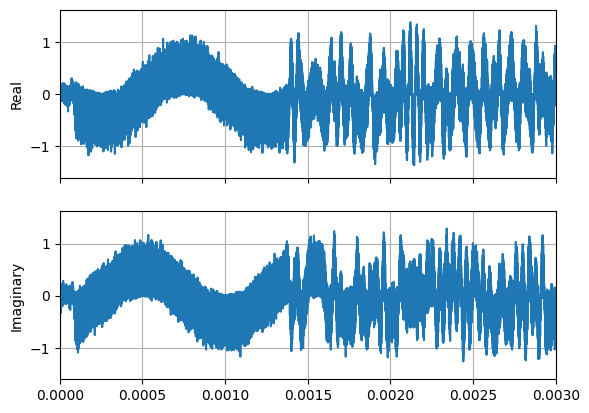

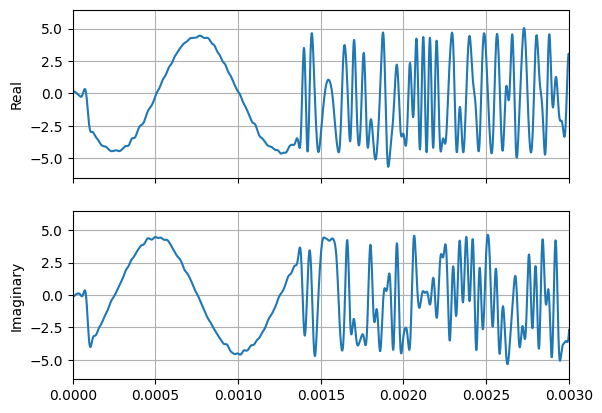

In [137]:
phase_offset = 11*np.pi/37
cfo = fc * 0.001
gain = 1

lo = gain * np.exp(-2j*np.pi*(fc + cfo)*trx + phase_offset)

# demod_filt = signal.iirdesign(wp=(fc/8), ws=(fc/2), gpass=1, gstop=120, ftype='cheby2', fs=fs, output='sos')
# y = signal.sosfilt(demod_filt, (noisy_chout * lo)).T
# w, h = signal.freqz_sos(demod_filt, fs=fs)
# fig, (ax0, ax1) = plt.subplots(2, 1)
# ax0.plot(w, 20*np.log10(np.abs(h)))
# ax0.grid()
# ax1.plot(w, np.angle(h)/np.pi)
# ax1.grid()
# fig.show()
# for i in range(len(demod_filt)):
#   write_mem_file(demod_filt[i][0:3], DWIDTH, DFRAC, f"demod_iir_{i}_num.mem")
#   write_mem_file(demod_filt[i][3:6], DWIDTH, DFRAC, f"demod_iir_{i}_den.mem")

# demod_filt = signal.minimum_phase(signal.firwin(7, fc/4, fs=fs), half=False)
# # demod_filt = signal.firwin(7, fc/4, fs=fs)
# y = np.convolve((noisy_chout * lo), demod_filt, 'same')
# w, h = signal.freqz(demod_filt, fs=fs)
# fig, (ax0, ax1) = plt.subplots(2, 1)
# ax0.plot(w, 20*np.log10(np.abs(h)))
# ax0.grid()
# ax1.plot(w, np.angle(h)/np.pi)
# ax1.grid()
# fig.show()
# write_mem_file(demod_filt, DWIDTH, DFRAC, "demod_fir.mem")

# print(demod_filt)

y = noisy_chout * lo

plot_complex_time_sequence(y, fs)
plt.xlim((0, 0.003))
plt.show()

# yhat = np.convolve(np.squeeze(y), rrc, 'same')
yhat = signal.resample_poly(np.squeeze(y), 1, sps//sps_rx, window=rrc)
fig, ax1, ax2 = plot_complex_time_sequence(yhat, br*sps_rx)
plt.xlim((0, 0.003))
plt.show()
# animate_complex_sequence(yhat[t < 0.00125], 'Simulated CFO', 'cfo.mp4', sps=360)

[ 0.33806232+5.12536195e-18j  0.29669682+1.09005779e-02j
  0.23525264+2.49718505e-02j  0.15736065+4.13428578e-02j
  0.0683052 +5.85932641e-02j -0.02542687+7.48286502e-02j
 -0.11673936+8.78360315e-02j -0.19859737+9.53098276e-02j
 -0.26470049+9.51269853e-02j -0.31008199+8.56402842e-02j
 -0.33156654+6.59526860e-02j -0.32806873+3.61667916e-02j
 -0.30060814-2.52292077e-03j -0.25209386-4.78679303e-02j
 -0.18699203-9.66587937e-02j -0.1108261 -1.44968767e-01j
 -0.02960279-1.88498590e-01j  0.05076607-2.22987856e-01j
  0.12497984-2.44648202e-01j  0.18874941-2.50568796e-01j
  0.23904616-2.39046156e-01j  0.27414142-2.09789123e-01j
  0.29358128-1.63998963e-01j  0.29805254-1.04299930e-01j
  0.28906239-3.45045329e-02j  0.26861865+4.07335510e-02j
  0.23891931+1.16347242e-01j  0.20209276+1.87315731e-01j
  0.16001754+2.49104501e-01j  0.11423512+2.98037944e-01j
  0.06595269+3.31566543e-01j  0.01607282+3.48404891e-01j
 -0.03463903+3.48533512e-01j -0.08535577+3.33074314e-01j
 -0.13511263+3.04064206e-01j -0

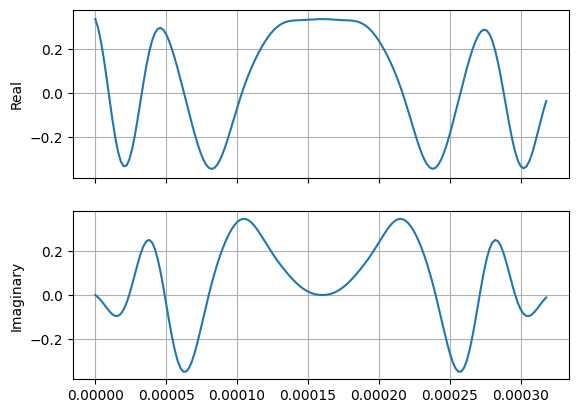

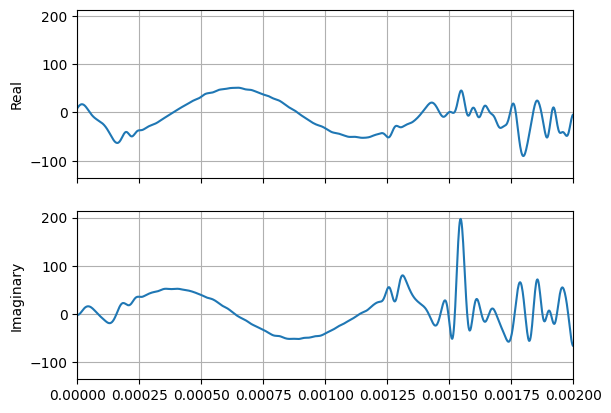

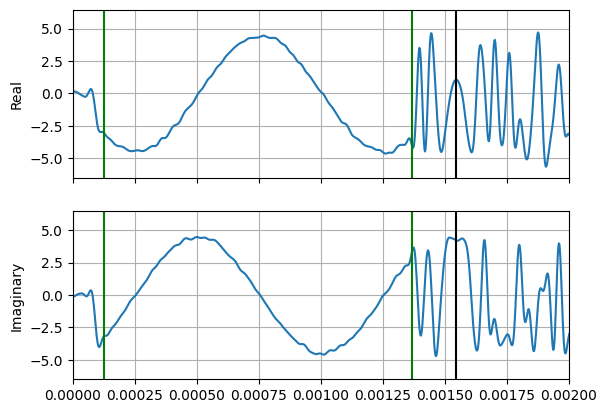

In [ ]:
zch_rc = np.convolve(upsample(zadoff_chu_seq, sps_rx), get_rc_pulse(beta, span, sps_rx), 'same')
plot_complex_time_sequence(zch_rc, fs / sps_rx)
# Convolving with reversed and conjugated window has the effect of cross correlation
write_mem_file(np.conj(zch_rc)[::-1], 32, DFRAC, 'zadoff_chu_rc.mem', complex=True, sep=' ')
print(np.conj(zch_rc))
xcorr = np.abs(np.correlate(yhat, zch_rc, 'same'))
plot_complex_time_sequence(np.correlate(yhat, zch_rc, 'same'), br*sps_rx)
plt.xlim((0, 0.002))
plt.show()
sync_point = np.argmax(xcorr)
pilot_end = sync_point - (sps_rx + len(zch_rc)//2)
pilot_start = pilot_end - (sync_len*sps_rx) + (sps_rx*2)
msg_start = sync_point + ((zadoff_chu_len)*sps_rx)//2 - 1

# plot_complex_time_sequence(xcorr, br*sps_rx)
t_sps_rx = np.arange(0, len(yhat)) / (br*sps_rx)
# plt.figure()
# plt.plot(t_sps_rx, np.real(yhat), 'o-')
# plt.plot(t_sps_rx, np.imag(yhat), 'o-')
fig, ax1, ax2 = plot_complex_time_sequence(yhat, br*sps_rx)
for axis in [ax1, ax2]:
  axis.axvline(x=(t_sps_rx[sync_point]), color='k')
  axis.axvline(x=(t_sps_rx[pilot_end]), color='g')
  axis.axvline(x=(t_sps_rx[pilot_start]), color='g')
plt.xlim((0, 0.002))
plt.show()
        

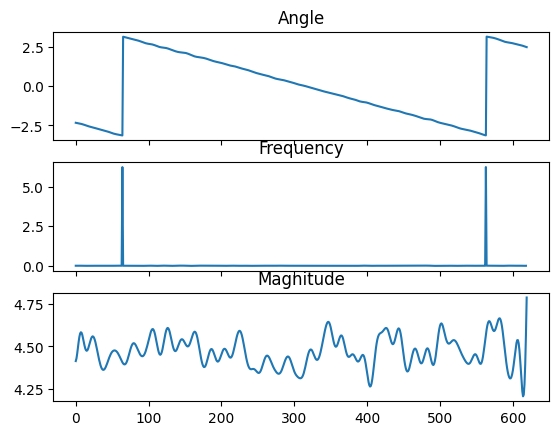

In [139]:
pilot_tone = yhat[pilot_start:pilot_end]
phase_err = np.angle(pilot_tone)
frq_err = phase_err[1:] - phase_err[:-1]
mag_err = np.abs(pilot_tone)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)
ax1.set_title('Angle')
ax2.set_title('Frequency')
ax3.set_title('Magnitude')
ax1.plot(phase_err)
ax2.plot(frq_err)
ax3.plot(mag_err)
plt.show()
freq_est = np.mean(frq_err[np.abs(frq_err) < 0.1])
phase_est = np.angle(yhat[pilot_start]) - (freq_est*pilot_start)
mag_est = np.mean(mag_err)


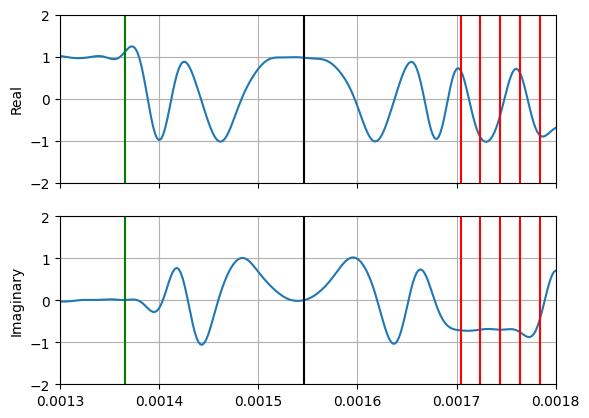

In [140]:
zhat = yhat / (mag_est*np.exp(1j*(np.arange(len(yhat))*freq_est + phase_est)))
fig, ax1, ax2 = plot_complex_time_sequence(zhat, br*sps_rx)
for axis in [ax1, ax2]:
  axis.axvline(x=(t_sps_rx[sync_point]), color='k')
  axis.axvline(x=(t_sps_rx[pilot_end]), color='g')
  axis.axvline(x=(t_sps_rx[pilot_start]), color='g')
  for i in range(len(words)):
    axis.axvline(x=(t_sps_rx[msg_start + (i*sps_rx)]), color='r')
  
# xhat = signal.resample_poly(full_msg, 1, sps//sps_rx, window=rrc) / 120
# ax1.plot(np.arange(len(xhat))/(br*sps_rx), np.real(xhat))
# ax2.plot(np.arange(len(xhat))/(br*sps_rx), np.imag(xhat))

plt.xlim((0.0013, 0.0018))
plt.ylim((-2, 2))
plt.show()

In [141]:
mhat = downsample(zhat[msg_start:], sps_rx)[:len(words)]
s_hat = min_dist_detection(mhat, constellation)
print(calc_error_rate(symbs, s_hat))

0.0


In [142]:
w_hat = np.empty_like(s_hat, dtype=np.uint8)
for i in range(M):
  w_hat[s_hat == constellation[i]] = i
print(words2str(w_hat, M))

A perfectly acceptable example of an extremely verbose message of large words and many characters!!!


In [143]:
frq_filt = signal.iirfilter(2, fc * 0.0015, btype='lowpass', fs=br*sps_rx)
print(frq_filt)
b, a = frq_filt
write_mem_file(b, 28, 24, "frq_iir_num.mem")
write_mem_file(a, 28, 24, "frq_iir_den.mem")

(array([8.76555488e-05, 1.75311098e-04, 8.76555488e-05]), array([ 1.        , -1.97334425,  0.97369487]))


[[ 0.00151757  0.         -0.00151757  1.         -0.51485166  0.64558258]
 [ 1.          0.61403117  1.          1.         -0.35196055  0.6963371 ]
 [ 1.         -1.49272493  1.          1.         -0.70461156  0.71406529]
 [ 1.          0.09635702  1.          1.         -0.28640286  0.81545512]
 [ 1.         -1.20321261  1.          1.         -0.82967872  0.8318747 ]
 [ 1.         -0.04614382  1.          1.         -0.28006667  0.93861232]
 [ 1.         -1.10832528  1.          1.         -0.90174578  0.94485595]]


C:\Users\sidal\AppData\Local\Temp\ipykernel_15464\817524147.py:5: RuntimeWarning: divide by zero encountered in log10
  ax0.plot(w, 20*np.log10(np.abs(h)))
C:\Users\sidal\AppData\Local\Temp\ipykernel_15464\817524147.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


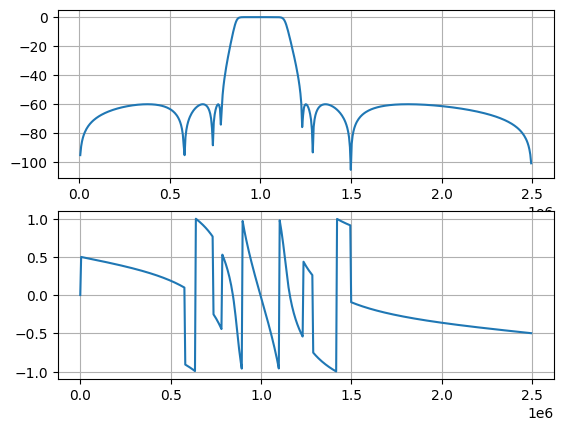

In [144]:
rx_filt = signal.iirdesign(wp=(fc - B/2, fc + B/2), ws=(fc - B, fc + B), 
                           gpass=1, gstop=60, output='sos', fs=fs, ftype='cheby2')
w, h = signal.freqz_sos(rx_filt, fs=fs)
fig, (ax0, ax1) = plt.subplots(2, 1)
ax0.plot(w, 20*np.log10(np.abs(h)))
ax0.grid()
ax1.plot(w, np.angle(h)/np.pi)
ax1.grid()
fig.show()
print(rx_filt)
write_mem_file(rx_filt.flatten(), DWIDTH, DFRAC, "rx_iir.mem")